# 6. Integrated Hexagonal Grid Map

This notebook creates an integrated hexagonal grid map by combining multiple data layers:
1. Response layer (mitigation zones)
2. Risk layer (flood zones)
3. Vulnerability layer
4. Socioeconomic layers (gini index and median income)

The notebook performs the following operations:
1. Generates a hexagonal grid map with 100m edge length
2. Loads each geojson hexagonal grid layer
3. Integrates all layers into a single map with uniquely named columns
4. Plots individual layer maps and the integrated map
5. Saves the integrated map as geojson for future processing (preserving raw values)

In [2]:
# Install required packages if necessary
# %pip install geopandas osmnx folium matplotlib shapely pyproj h3 verus contextily

In [3]:
# Import required libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
import contextily as ctx 
warnings.filterwarnings('ignore')

# Import the VERUS grid generator
from verus.grid import HexagonGridGenerator

/Volumes/Hercules/Developer/multilayer-priority/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 6.1. Generate Hexagonal Grid Map

In [4]:
city = 'Lisbon'
# scenario = 1

# Configure fonts for the plots
plt.rcParams.update(
    {
        "font.size": 16,
        "font.family": "Times New Roman",
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

In [5]:
# Define CRS
wgs84_crs = "EPSG:4326"  # WGS84 for geometry queries
portugal_metric_crs = "EPSG:3763"  # ETRS89 / Portugal TM06 for area calculations

# Get city boundaries
# city_gdf = ox.geocode_to_gdf(f"{city}, Portugal").to_crs(wgs84_crs)
city_gdf = gpd.read_file(f"../data/cities/{city.lower()}.geojson")
city_polygon = city_gdf.geometry.iloc[0]
city_centroid_latlon = city_gdf.to_crs(wgs84_crs).geometry.centroid.iloc[0].coords[0][::-1]

In [6]:
# Function to generate hexagonal grid
def create_hexagonal_grid(city_polygon, edge_length=100):
    # Use VERUS library to create the grid
    grid_gen = HexagonGridGenerator(
        region=f"../data/cities/{city.lower()}.geojson",
        edge_length=edge_length,
    )
    hex_grid = grid_gen.run()
    return hex_grid

# Create hexagonal grid
try:
    hex_grid = create_hexagonal_grid(city_polygon, edge_length=100)
    print(f"Successfully created hexagonal grid with {len(hex_grid)} cells")
except Exception as e:
    print(f"Error creating hexagonal grid: {e}")
    print("Loading pre-existing grid from one of the data files...")
    response_layer_path = f"data/response_layer/{city}_hexagonal_mitigation_zones.geojson"
    hex_grid = gpd.read_file(response_layer_path)
    # Keep only hex_id and geometry
    hex_grid = hex_grid[['hex_id', 'geometry']].copy()

2025-06-03 15:01:38 [INFO] Initialized grid generator for region from file: lisbon.geojson
2025-06-03 15:01:38 [INFO] Processing region
2025-06-03 15:01:38 [INFO] Loading region boundary from file: ../data/cities/lisbon.geojson
2025-06-03 15:01:38 [INFO] Generating hexagonal grid with edge length 100m
2025-06-03 15:01:38 [INFO] Generated 11131 hexagons
2025-06-03 15:01:39 [INFO] Assigning random values between 0 and 1
2025-06-03 15:01:39 [INFO] Assigning colors based on values
2025-06-03 15:01:39 [INFO] Clipping grid to region boundaries
2025-06-03 15:01:39 [INFO] Clipped from 11131 to 6569 hexagons
Successfully created hexagonal grid with 6569 cells


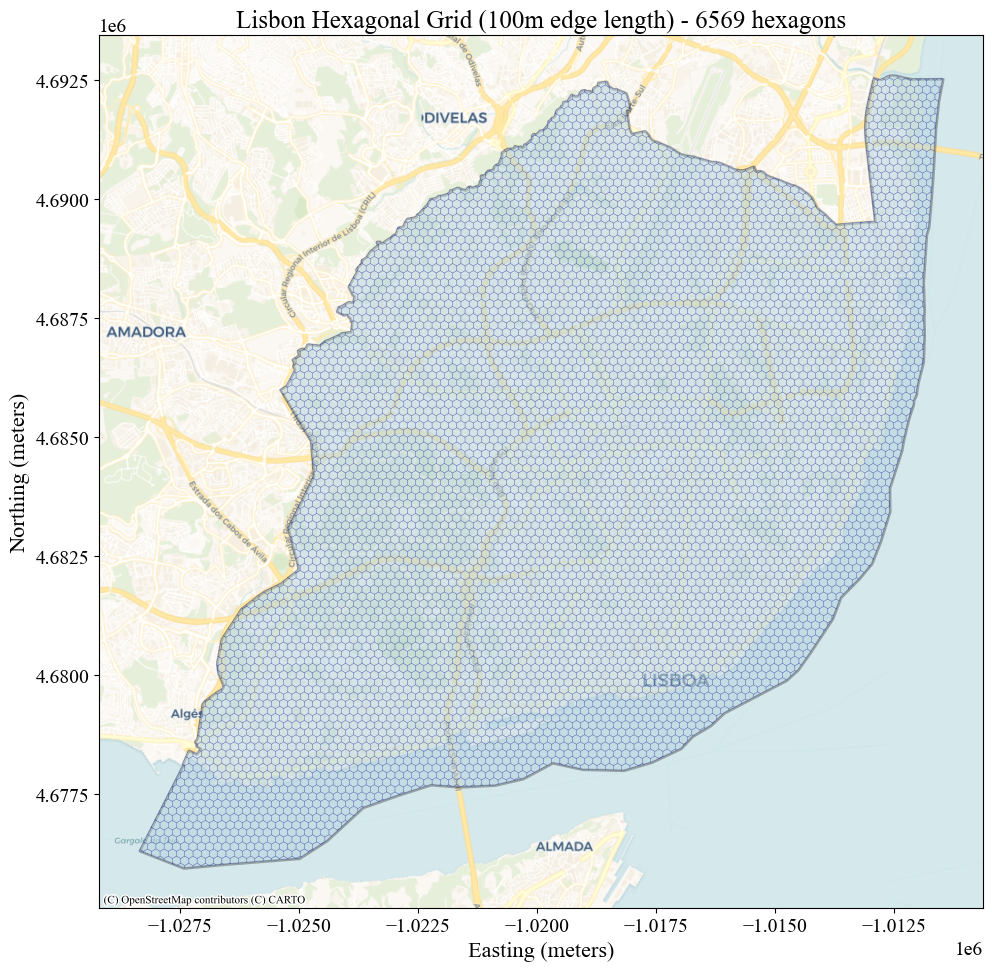

Hexagonal grid contains 6569 hexagons covering Lisbon


In [7]:
# Visualize the hexagonal grid
fig, ax = plt.subplots(figsize=(12, 10))

# Convert to Web Mercator (EPSG:3857) for contextily compatibility
city_gdf_mercator = city_gdf.to_crs(epsg=3857)
hex_grid_mercator = hex_grid.to_crs(epsg=3857)

# Plot the city boundaries and hexagonal grid
city_gdf_mercator.plot(
    ax=ax, color="lightgray", edgecolor="black", linewidth=2, alpha=0.3
)
hex_grid_mercator.plot(
    ax=ax, color="lightblue", edgecolor="darkblue", linewidth=0.3, alpha=0.4
)

# Add contextily basemap
ctx.add_basemap(ax, crs=city_gdf_mercator.crs, source=ctx.providers.CartoDB.Voyager)
# ctx.add_basemap(ax, crs=city_gdf_mercator.crs, source=ctx.providers.Esri.WorldImagery)

ax.set_title(f"{city} Hexagonal Grid (100m edge length) - {len(hex_grid)} hexagons")
ax.set_xlabel("Easting (meters)")
ax.set_ylabel("Northing (meters)")
plt.tight_layout()
plt.show()

print(f"Hexagonal grid contains {len(hex_grid)} hexagons covering {city}")

## 6.2. Load Geojson Hexagonal Grid Layers

In [8]:
# Define paths to the different layer files
response_layer_path = f"../data/response_layer/{city}_mitigation_zones.geojson"
risk_layer_path = f"../data/risk_layer/{city}_flood_zones.geojson"
gini_layer_path = f"../data/socioeconomic_layer/{city}_gini_index.geojson"
income_layer_path = f"../data/socioeconomic_layer/{city}_median_income.geojson"

# For vulnerability, we have multiple scenarios - let's use scenario 1 for this example
# vulnerability_layer_path = f"../data/vulnerability_layer/{city.lower()}/{city}_vulnerability_zones_s{scenario}.geojson"

# Load vulnerability layers for all 4 scenarios
vulnerability_layers = {}
for s in range(1, 5):
    vulnerability_layer_path = f"../data/vulnerability_layer/{city.lower()}/{city}_vulnerability_zones_s{s}.geojson"
    vulnerability_layers[f"s{s}"] = gpd.read_file(vulnerability_layer_path)

# Load other layers
try:
    response_layer = gpd.read_file(response_layer_path)
    risk_layer = gpd.read_file(risk_layer_path)
    # vulnerability_layer = gpd.read_file(vulnerability_layer_path)
    gini_layer = gpd.read_file(gini_layer_path)
    income_layer = gpd.read_file(income_layer_path)
    
    print(f"Response layer: {len(response_layer)} hexagons")
    print(f"Risk layer: {len(risk_layer)} hexagons")
    # print(f"Vulnerability layer: {len(vulnerability_layer)} hexagons")
    for scenario, vuln_layer in vulnerability_layers.items():
        print(f"Vulnerability layer {scenario}: {len(vuln_layer)} hexagons") 
    print(f"Gini index layer: {len(gini_layer)} hexagons")
    print(f"Median income layer: {len(income_layer)} hexagons")
except Exception as e:
    print(f"Error loading layers: {e}")

Skipping field neighbors_other_clusters: unsupported OGR type: 1
Skipping field neighbors_other_clusters: unsupported OGR type: 1
Skipping field neighbors_other_clusters: unsupported OGR type: 1


Response layer: 6569 hexagons
Risk layer: 6569 hexagons
Vulnerability layer s1: 6569 hexagons
Vulnerability layer s2: 6569 hexagons
Vulnerability layer s3: 6569 hexagons
Vulnerability layer s4: 6569 hexagons
Gini index layer: 6569 hexagons
Median income layer: 6569 hexagons


In [9]:
# Describe the vulnerability values for each scenario
for scenario, vuln_layer in vulnerability_layers.items():
    print(f"Vulnerability layer {scenario} statistics:")
    print(vuln_layer["VL_normalized_smoothed"].describe())
    print()

Vulnerability layer s1 statistics:
count    6569.000000
mean        0.173610
std         0.141178
min         0.003276
25%         0.072934
50%         0.128117
75%         0.235639
max         0.935261
Name: VL_normalized_smoothed, dtype: float64

Vulnerability layer s2 statistics:
count    6569.000000
mean        0.523592
std         0.161466
min         0.000000
25%         0.418718
50%         0.525212
75%         0.636200
max         1.000000
Name: VL_normalized_smoothed, dtype: float64

Vulnerability layer s3 statistics:
count    6569.000000
mean        0.394840
std         0.118846
min         0.000000
25%         0.319038
50%         0.405524
75%         0.483704
max         0.687804
Name: VL_normalized_smoothed, dtype: float64

Vulnerability layer s4 statistics:
count    6569.000000
mean        0.513965
std         0.151000
min         0.000000
25%         0.419683
50%         0.525137
75%         0.619208
max         0.893073
Name: VL_normalized_smoothed, dtype: float64



In [10]:
# Examine the structure of each layer
print("Layer columns:")
print(f"Response: {list(response_layer.columns)}")
print(f"Risk: {list(risk_layer.columns)}")
# print(f"Vulnerability: {list(vulnerability_layer.columns)}")
for scenario, vuln_layer in vulnerability_layers.items():
    print(f"Vulnerability {scenario}: {list(vuln_layer.columns)}")
print(f"Gini: {list(gini_layer.columns)}")
print(f"Income: {list(income_layer.columns)}")

Layer columns:
Response: ['hex_id', 'value', 'level', 'color', 'geometry']
Risk: ['hex_id', 'value', 'level', 'color', 'geometry']
Vulnerability s1: ['zone_id', 'hex_id', 'value', 'color', 'cluster', 'VL_normalized', 'neighbors_other_clusters', 'relative_influence', 'VL_normalized_smoothed', 'geometry']
Vulnerability s2: ['zone_id', 'hex_id', 'value', 'color', 'cluster', 'VL_normalized', 'relative_influence', 'VL_normalized_smoothed', 'geometry']
Vulnerability s3: ['zone_id', 'hex_id', 'value', 'color', 'cluster', 'VL_normalized', 'relative_influence', 'VL_normalized_smoothed', 'geometry']
Vulnerability s4: ['zone_id', 'hex_id', 'value', 'color', 'cluster', 'VL_normalized', 'relative_influence', 'VL_normalized_smoothed', 'geometry']
Gini: ['hex_id', 'gini', 'gini_index_level', 'color', 'geometry']
Income: ['hex_id', 'median_inc', 'median_income_level', 'geometry']


## 3. Integrate Layers and Replace Values with Descriptive Labels

In [11]:
# Define the source columns from each layer and their target names in the integrated grid
source_target_columns = {
    "response": {"source": "value", "target": "response_value"},
    "risk": {"source": "value", "target": "risk_value"},
    "vulnerability_s1": {
        "source": "VL_normalized_smoothed",
        "target": "vulnerability_s1_value",
    },
    "vulnerability_s2": {
        "source": "VL_normalized_smoothed",
        "target": "vulnerability_s2_value",
    },
    "vulnerability_s3": {
        "source": "VL_normalized_smoothed",
        "target": "vulnerability_s3_value",
    },
    "vulnerability_s4": {
        "source": "VL_normalized_smoothed",
        "target": "vulnerability_s4_value",
    },
    "gini": {"source": "gini", "target": "gini_value"},
    "income": {"source": "median_inc", "target": "income_value"},
}

# Function to create color scale for each layer
def get_color_scale(layer_name):
    color_scales = {
        "risk": "RdYlGn_r",
        "response": "Spectral_r",
        "vulnerability": "YlOrRd",
        "gini": "Blues_r",
        "income": "Purples_r",
    }
    return color_scales.get(layer_name, 'viridis')

In [12]:
# We're focusing only on the raw values - no need to calculate normalized values
# Create proper GeoDataFrames making sure to preserve the geometry column and CRS

# Function to create a proper GeoDataFrame copy with geometry
def create_geo_copy(gdf, columns):
    if 'geometry' not in columns:
        columns = list(columns) + ['geometry']
    return gpd.GeoDataFrame(gdf[columns], geometry='geometry', crs=gdf.crs)

# Response Layer - using 'value' column
response_data = create_geo_copy(response_layer, ['hex_id', 'value'])

# Risk Layer - using 'value' column
risk_data = create_geo_copy(risk_layer, ['hex_id', 'value'])

# Vulnerability Layer - using 'VL_normalized_smoothed' column
# vulnerability_data = create_geo_copy(vulnerability_layer, ['hex_id', 'VL_normalized_smoothed'])
# Vulnerability Layers - using 'VL_normalized_smoothed' column for all scenarios
vulnerability_data = {}
for scenario, vuln_layer in vulnerability_layers.items():
    vulnerability_data[scenario] = create_geo_copy(
        vuln_layer, ["hex_id", "VL_normalized_smoothed"]
    )

# Gini Layer - using 'gini' column
gini_data = create_geo_copy(gini_layer, ['hex_id', 'gini'])

# Income Layer - using 'median_inc' column
income_data = create_geo_copy(income_layer, ['hex_id', 'median_inc'])

# Print shapes to verify data
print(f"Response data: {response_data.shape}")
print(f"Risk data: {risk_data.shape}")
# print(f"Vulnerability data: {vulnerability_data.shape}")
for scenario, vuln_data in vulnerability_data.items():
    print(f"Vulnerability data {scenario}: {vuln_data.shape}")
print(f"Gini data: {gini_data.shape}")
print(f"Income data: {income_data.shape}")

# Additional verification for response data
print("\nResponse data structure verification:")
print(f"First few records of response_data:\n{response_data.head(3)}")
print(f"Are geometries valid: {all(response_data.geometry.is_valid)}")
print(f"Non-null values: {response_data['value'].count()} out of {len(response_data)}")

Response data: (6569, 3)
Risk data: (6569, 3)
Vulnerability data s1: (6569, 3)
Vulnerability data s2: (6569, 3)
Vulnerability data s3: (6569, 3)
Vulnerability data s4: (6569, 3)
Gini data: (6569, 3)
Income data: (6569, 3)

Response data structure verification:
First few records of response_data:
    hex_id     value                                           geometry
0     h_10  0.857602  POLYGON ((-9.22238 38.68073, -9.22204 38.68058...
1   h_1000  0.574191  POLYGON ((-9.21383 38.6902, -9.2146 38.68985, ...
2  h_10000  0.574416  POLYGON ((-9.15703 38.78585, -9.15781 38.7855,...
Are geometries valid: True
Non-null values: 6569 out of 6569


In [13]:
# Create integrated layer by merging all layers based on hex_id

# Start with base grid
integrated_grid = hex_grid.copy()

# Keep only necessary columns for each dataframe before merging
# Add response layer - rename 'value' to 'response_value'
response_data_renamed = response_data.rename(columns={
    source_target_columns['response']['source']: source_target_columns['response']['target']
})
integrated_grid = integrated_grid.merge(
    response_data_renamed[['hex_id', source_target_columns['response']['target']]],
    on='hex_id',
    how='left'
)

# Add risk layer - rename 'value' to 'risk_value'
risk_data_renamed = risk_data.rename(columns={
    source_target_columns['risk']['source']: source_target_columns['risk']['target']
})
integrated_grid = integrated_grid.merge(
    risk_data_renamed[['hex_id', source_target_columns['risk']['target']]],
    on='hex_id',
    how='left'
)

# Add all vulnerability layers
for scenario, vuln_data in vulnerability_data.items():
    scenario_key = f"vulnerability_{scenario}"
    vuln_data_renamed = vuln_data.rename(
        columns={
            source_target_columns[scenario_key]["source"]: source_target_columns[
                scenario_key
            ]["target"]
        }
    )
    integrated_grid = integrated_grid.merge(
        vuln_data_renamed[["hex_id", source_target_columns[scenario_key]["target"]]],
        on="hex_id",
        how="left",
    )

# Add gini layer - rename 'gini' to 'gini_value'
gini_data_renamed = gini_data.rename(columns={
    source_target_columns['gini']['source']: source_target_columns['gini']['target']
})
integrated_grid = integrated_grid.merge(
    gini_data_renamed[['hex_id', source_target_columns['gini']['target']]],
    on='hex_id',
    how='left'
)

# Add income layer - rename 'median_inc' to 'income_value'
income_data_renamed = income_data.rename(columns={
    source_target_columns['income']['source']: source_target_columns['income']['target']
})
integrated_grid = integrated_grid.merge(
    income_data_renamed[['hex_id', source_target_columns['income']['target']]],
    on='hex_id',
    how='left'
)

# Check the integrated grid
print(f"Integrated grid shape: {integrated_grid.shape}")
print("Columns:")
print(integrated_grid.columns)

Integrated grid shape: (6569, 12)
Columns:
Index(['geometry', 'hex_id', 'value', 'color', 'response_value', 'risk_value',
       'vulnerability_s1_value', 'vulnerability_s2_value',
       'vulnerability_s3_value', 'vulnerability_s4_value', 'gini_value',
       'income_value'],
      dtype='object')


In [14]:
# Handle possible missing values by filling numeric missing values with 0
numeric_columns = [
    "response_value",
    "risk_value",
    "vulnerability_s1_value",
    "vulnerability_s2_value",
    "vulnerability_s3_value",
    "vulnerability_s4_value",
    "gini_value",
    "income_value",
]

# Fill numeric missing values with 0
integrated_grid[numeric_columns] = integrated_grid[numeric_columns].fillna(0)

# Check the columns in the integrated grid
print("Numeric columns after filling NA values:")
for col in numeric_columns:
    if col in integrated_grid.columns:
        print(f"- {col}: {integrated_grid[col].isna().sum()} NA values")
    else:
        print(f"- {col}: not found in dataframe")

Numeric columns after filling NA values:
- response_value: 0 NA values
- risk_value: 0 NA values
- vulnerability_s1_value: 0 NA values
- vulnerability_s2_value: 0 NA values
- vulnerability_s3_value: 0 NA values
- vulnerability_s4_value: 0 NA values
- gini_value: 0 NA values
- income_value: 0 NA values


In [15]:
# Describe the vulnerability layers
for scenario, vuln_layer in vulnerability_layers.items():
    print(f"\nVulnerability Layer {scenario} Description:")
    print(vuln_layer["VL_normalized_smoothed"].describe())


Vulnerability Layer s1 Description:
count    6569.000000
mean        0.173610
std         0.141178
min         0.003276
25%         0.072934
50%         0.128117
75%         0.235639
max         0.935261
Name: VL_normalized_smoothed, dtype: float64

Vulnerability Layer s2 Description:
count    6569.000000
mean        0.523592
std         0.161466
min         0.000000
25%         0.418718
50%         0.525212
75%         0.636200
max         1.000000
Name: VL_normalized_smoothed, dtype: float64

Vulnerability Layer s3 Description:
count    6569.000000
mean        0.394840
std         0.118846
min         0.000000
25%         0.319038
50%         0.405524
75%         0.483704
max         0.687804
Name: VL_normalized_smoothed, dtype: float64

Vulnerability Layer s4 Description:
count    6569.000000
mean        0.513965
std         0.151000
min         0.000000
25%         0.419683
50%         0.525137
75%         0.619208
max         0.893073
Name: VL_normalized_smoothed, dtype: float64


## 6.4. Plot Maps for Each Index

In [16]:
# Add a colorbar legend at the bottom
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

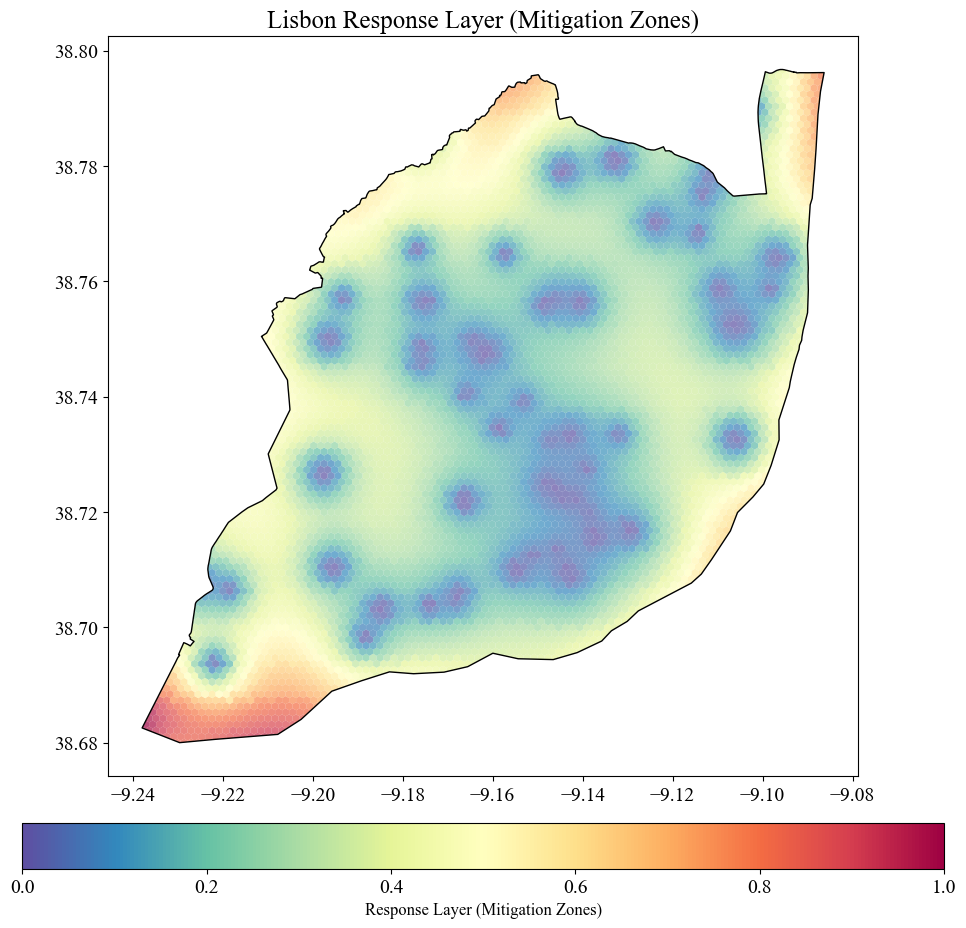

In [17]:
# Create map for response layer using the raw values
fig, ax = plt.subplots(figsize=(12, 10))

# Plot city boundary first
city_gdf.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot response data
plot = response_data.plot(
    column="value",
    cmap=get_color_scale('response'),
    ax=ax,
    legend=False,  # Don't add the legend yet
    alpha=0.7,
)

norm = Normalize(vmin=response_data['value'].min(), vmax=response_data['value'].max())
sm = ScalarMappable(norm=norm, cmap=get_color_scale("response"))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Response Layer (Mitigation Zones)', fontsize=12)

ax.set_title(f"{city} Response Layer (Mitigation Zones)")
plt.tight_layout()
plt.show()

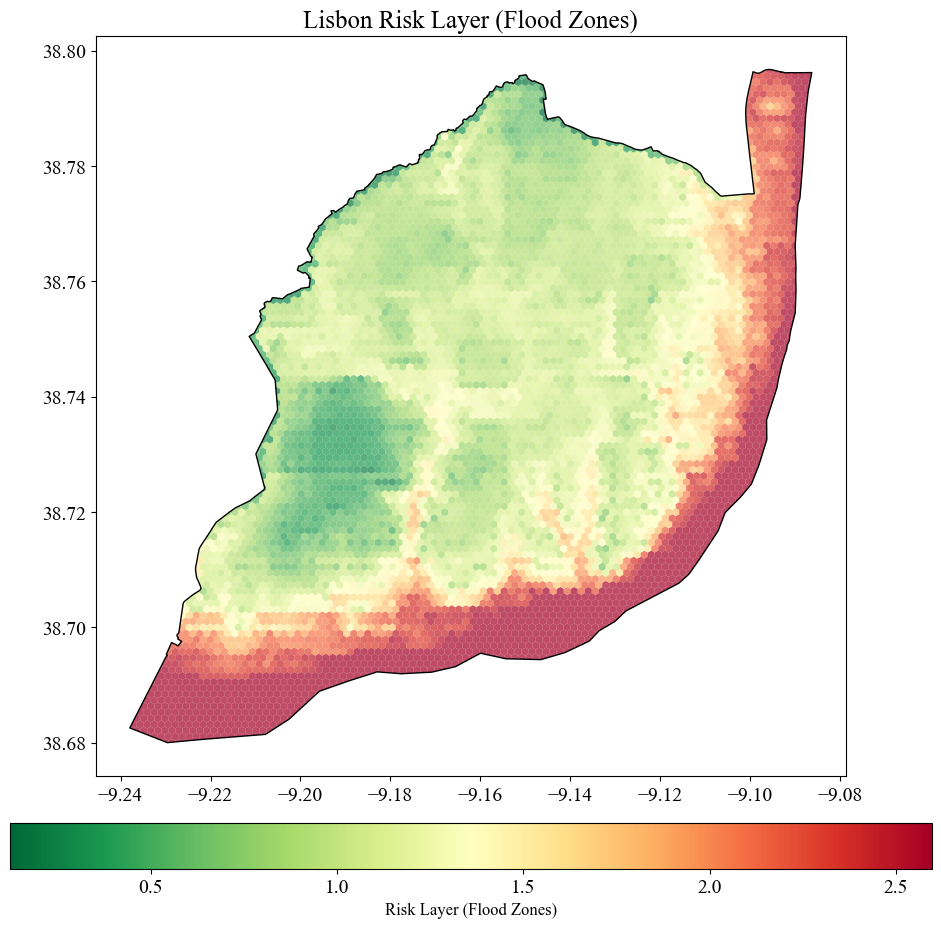

In [18]:
# Create map for risk layer using the raw values
fig, ax = plt.subplots(figsize=(12, 10))
city_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
plot = risk_data.plot(
    column='value', 
    cmap=get_color_scale('risk'),
    ax=ax,
    legend=False,  # Don't add the legend yet
    alpha=0.7
)

norm = Normalize(vmin=risk_data['value'].min(), vmax=risk_data['value'].max())
sm = ScalarMappable(norm=norm, cmap=get_color_scale('risk'))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Risk Layer (Flood Zones)', fontsize=12)

ax.set_title(f"{city} Risk Layer (Flood Zones)")
plt.tight_layout()
plt.show()

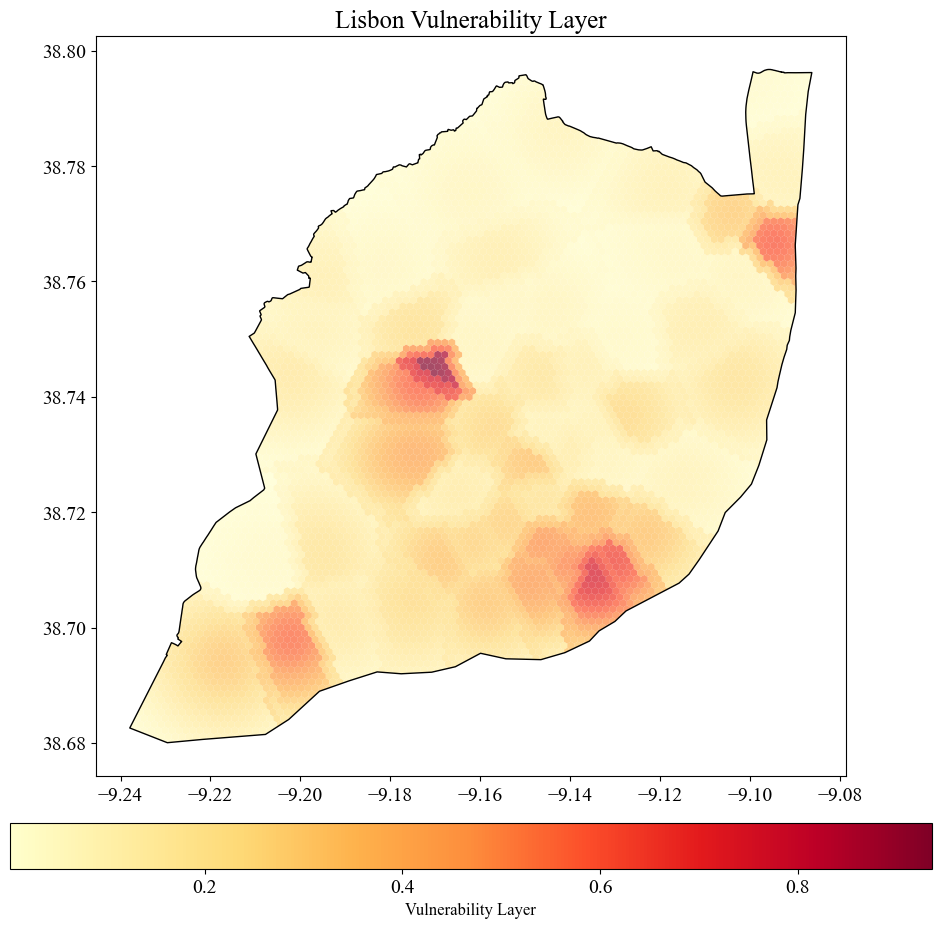

In [19]:
# Add a colorbar legend at the bottom
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Create map for vulnerability layer using the VL_normalized_smoothed values
fig, ax = plt.subplots(figsize=(12, 10))
city_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
plot = vulnerability_data["s1"].plot(
    column="VL_normalized_smoothed",
    cmap=get_color_scale("vulnerability"),
    ax=ax,
    legend=False,  # Don't add the legend yet
    alpha=0.7,
)

norm = Normalize(
    vmin=vulnerability_data["s1"]["VL_normalized_smoothed"].min(),
    vmax=vulnerability_data["s1"]["VL_normalized_smoothed"].max(),
)
sm = ScalarMappable(norm=norm, cmap=get_color_scale('vulnerability'))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Vulnerability Layer', fontsize=12)

ax.set_title(f"{city} Vulnerability Layer")
plt.tight_layout()
plt.show()

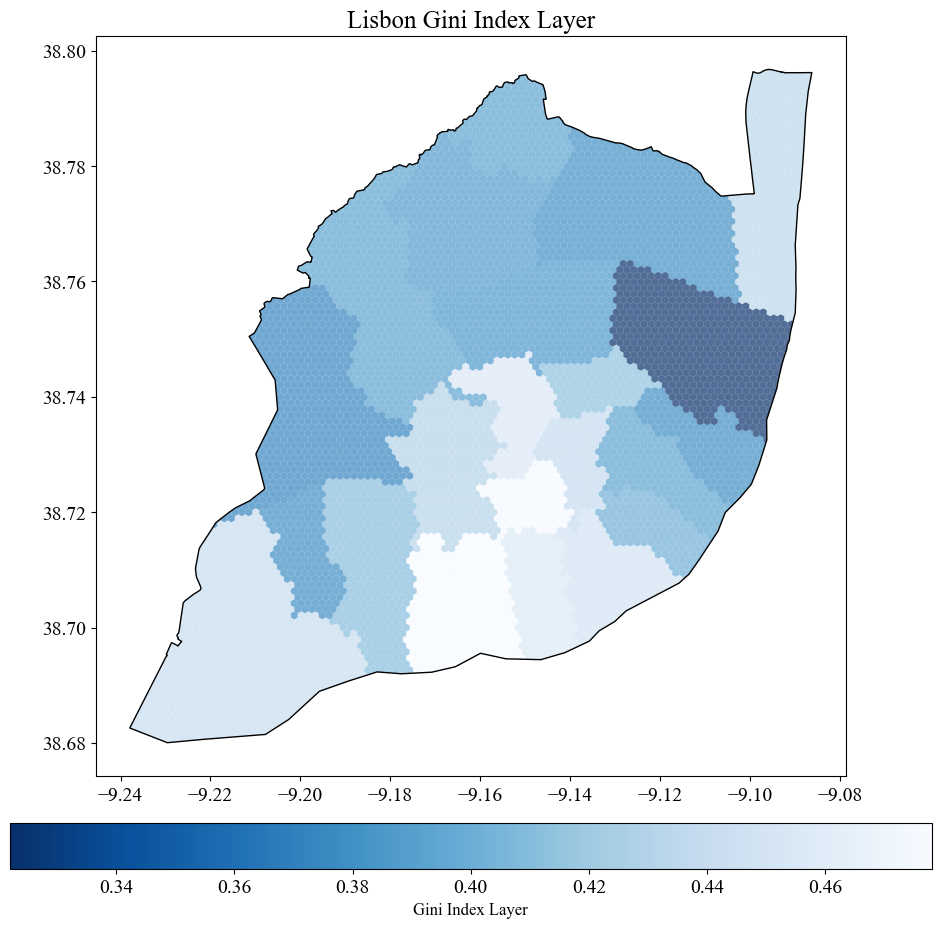

In [20]:
# Create map for gini layer using the raw gini values
fig, ax = plt.subplots(figsize=(12, 10))
city_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
plot = gini_data.plot(
    column='gini', 
    cmap=get_color_scale('gini'),
    ax=ax,
    legend=False,  # Don't add the legend yet
    alpha=0.7
)

norm = Normalize(vmin=gini_data['gini'].min(), vmax=gini_data['gini'].max())
sm = ScalarMappable(norm=norm, cmap=get_color_scale('gini'))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Gini Index Layer', fontsize=12)

ax.set_title(f'{city} Gini Index Layer')
plt.tight_layout()
plt.show()

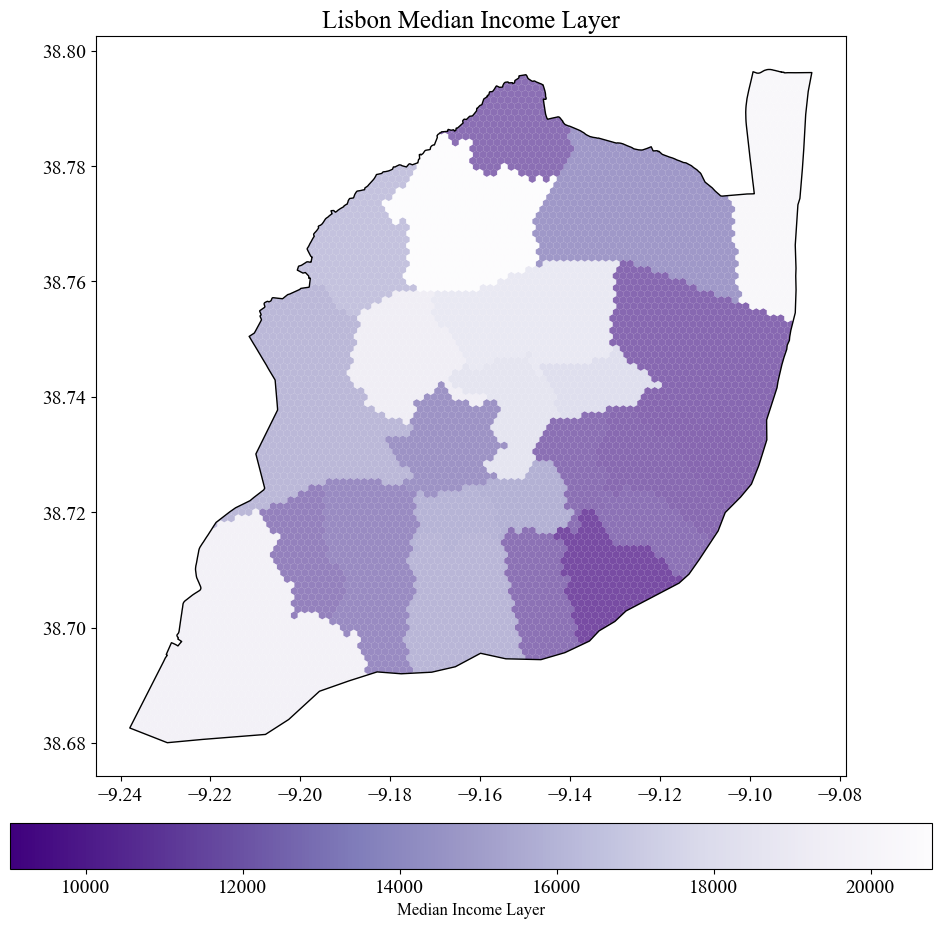

In [21]:
# Create map for income layer using the raw median income values
fig, ax = plt.subplots(figsize=(12, 10))
city_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
plot = income_data.plot(
    column='median_inc', 
    cmap=get_color_scale('income'),
    ax=ax,
    legend=False,  # Don't add the legend yet
    alpha=0.7
)

norm = Normalize(vmin=income_data['median_inc'].min(), vmax=income_data['median_inc'].max())
sm = ScalarMappable(norm=norm, cmap=get_color_scale('income'))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Median Income Layer', fontsize=12)

ax.set_title(f"{city} Median Income Layer")
plt.tight_layout()
plt.show()

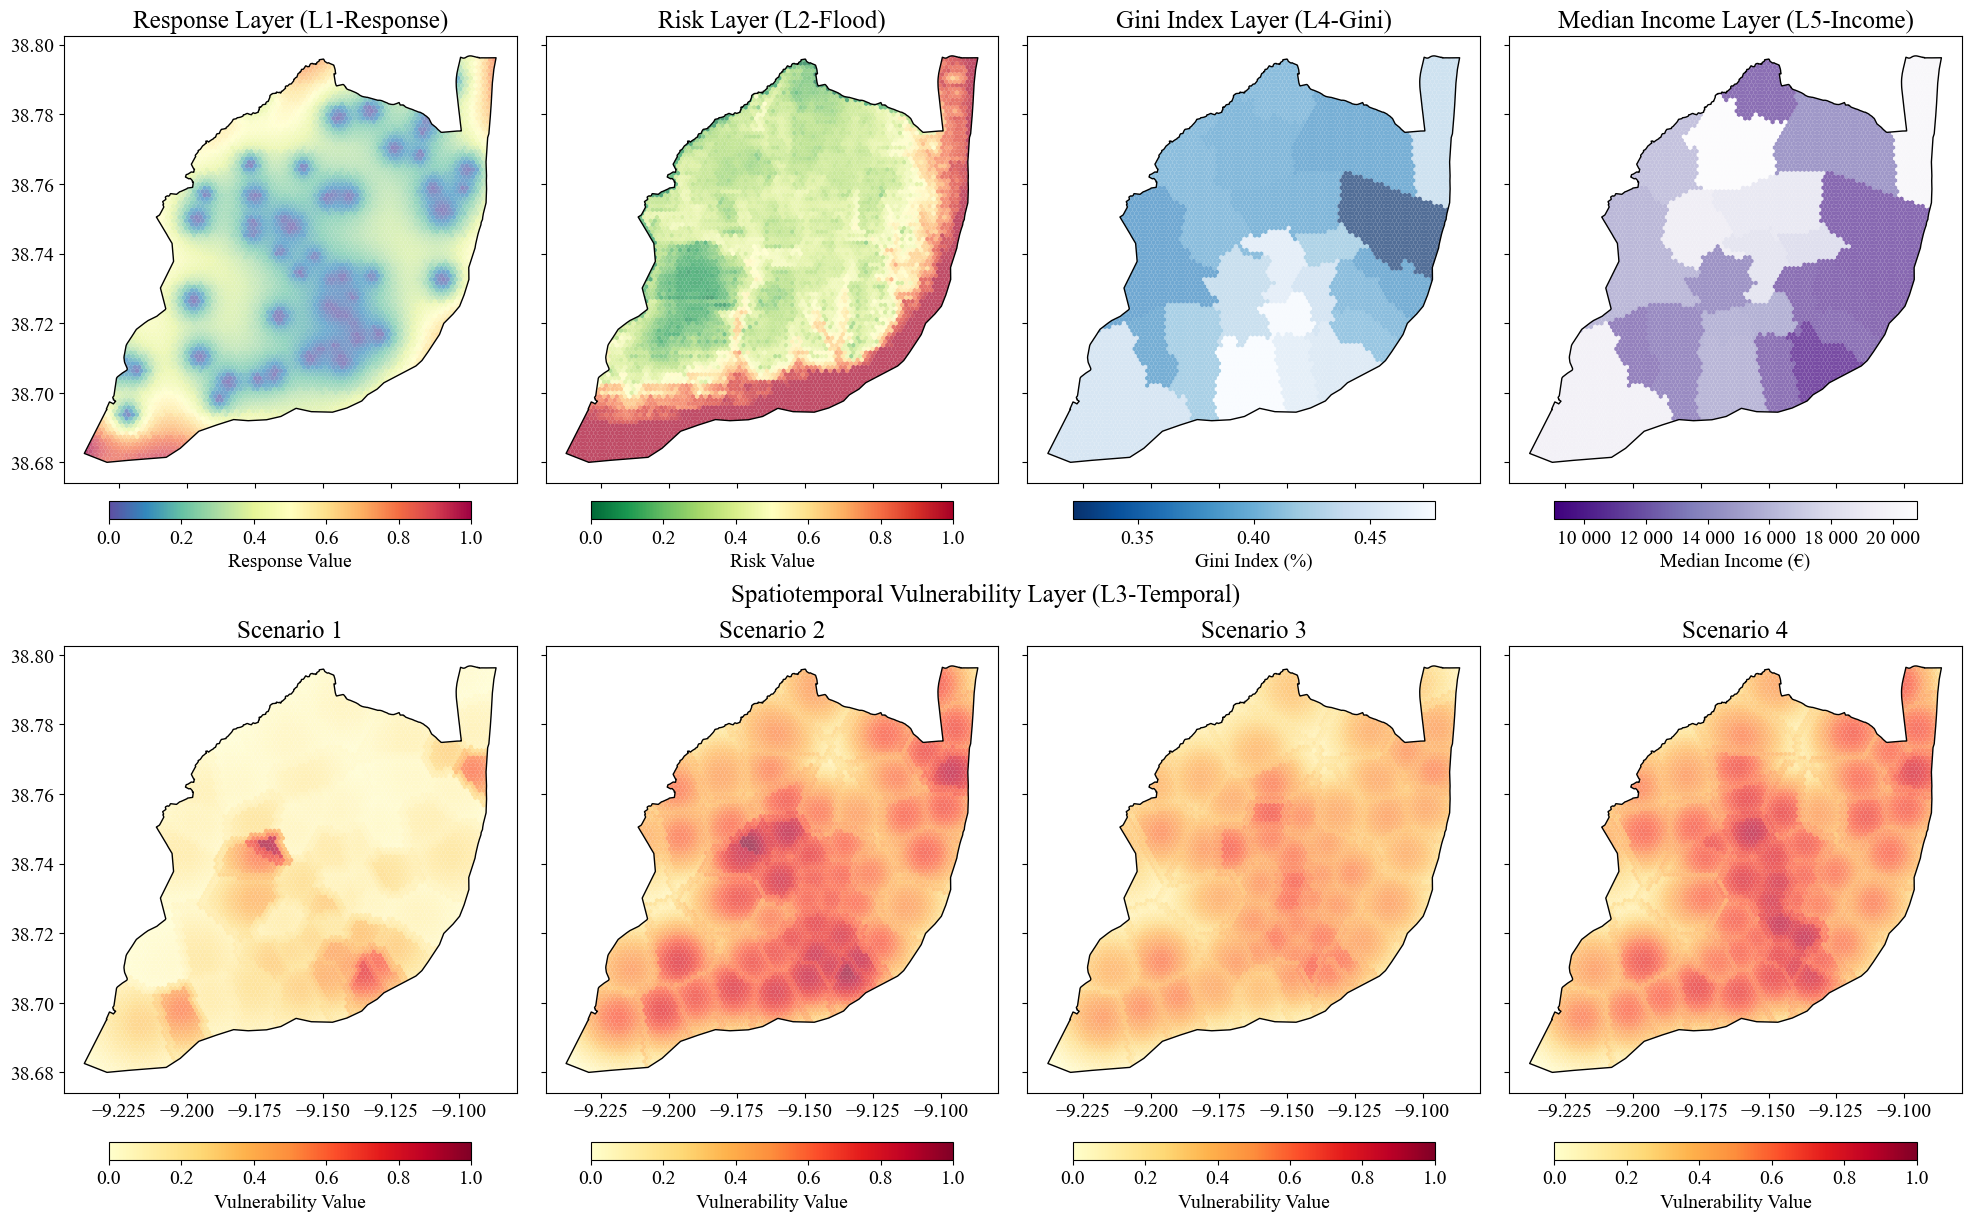

In [22]:
from matplotlib.ticker import FuncFormatter


# Define a formatter function for thousands with spaces
def thousands_formatter(x, pos):
    return f"{int(x):,}".replace(",", " ")


# Create a multi-panel figure showing all layers with vulnerability scenarios in second row
fig, axes = plt.subplots(2, 4, figsize=(20, 13), sharex=True, sharey=True)

# First row: Response, Risk, Gini, Income
# Plot Response Layer
city_gdf.boundary.plot(ax=axes[0, 0], color="black", linewidth=1)
response_data.plot(
    column="value",
    cmap=get_color_scale("response"),
    ax=axes[0, 0],
    legend=False,
    alpha=0.7,
)
norm0 = Normalize(vmin=response_data["value"].min(), vmax=response_data["value"].max())
sm0 = ScalarMappable(norm=norm0, cmap=get_color_scale("response"))
sm0.set_array([])
cbar0 = fig.colorbar(
    sm0, ax=axes[0, 0], orientation="horizontal", pad=0.03, shrink=0.8
)
cbar0.set_label("Response Value", fontsize=14)
# axes[0, 0].set_title("Response Layer (Mitigation Zones)")
axes[0, 0].set_title("Response Layer (L1-Response)")

# Plot Risk Layer
# Normalize risk values to 0-1 scale
risk_data["value_normalized"] = (risk_data["value"] - risk_data["value"].min()) / (
    risk_data["value"].max() - risk_data["value"].min()
)

city_gdf.boundary.plot(ax=axes[0, 1], color="black", linewidth=1)
risk_data.plot(
    column="value_normalized",
    cmap=get_color_scale("risk"),
    ax=axes[0, 1],
    legend=False,
    alpha=0.7,
    vmin=0,  # Use normalized values
    vmax=1,  # Use normalized values
)
norm1 = Normalize(vmin=0, vmax=1)
sm1 = ScalarMappable(norm=norm1, cmap=get_color_scale("risk"))
sm1.set_array([])
cbar1 = fig.colorbar(
    sm1, ax=axes[0, 1], orientation="horizontal", pad=0.03, shrink=0.8
)
cbar1.set_label("Risk Value", fontsize=14)
# axes[0, 1].set_title("Risk Layer (Flood Zones)")
axes[0, 1].set_title("Risk Layer (L2-Flood)")

# Plot Gini Layer
city_gdf.boundary.plot(ax=axes[0, 2], color="black", linewidth=1)
gini_data.plot(
    column="gini", cmap=get_color_scale("gini"), ax=axes[0, 2], legend=False, alpha=0.7
)
norm2 = Normalize(vmin=gini_data["gini"].min(), vmax=gini_data["gini"].max())
sm2 = ScalarMappable(norm=norm2, cmap=get_color_scale("gini"))
sm2.set_array([])
cbar2 = fig.colorbar(
    sm2, ax=axes[0, 2], orientation="horizontal", pad=0.03, shrink=0.8
)
cbar2.set_label("Gini Index (%)", fontsize=14)
axes[0, 2].set_title("Gini Index Layer (L4-Gini)")

# Plot Income Layer
city_gdf.boundary.plot(ax=axes[0, 3], color="black", linewidth=1)
income_data.plot(
    column="median_inc",
    cmap=get_color_scale("income"),
    ax=axes[0, 3],
    legend=False,
    alpha=0.7,
)
norm3 = Normalize(
    vmin=income_data["median_inc"].min(), vmax=income_data["median_inc"].max()
)
sm3 = ScalarMappable(norm=norm3, cmap=get_color_scale("income"))
sm3.set_array([])
cbar3 = fig.colorbar(
    sm3, ax=axes[0, 3], orientation="horizontal", pad=0.03, shrink=0.8
)

cbar3.ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))
cbar3.set_label("Median Income (€)", fontsize=14)
axes[0, 3].set_title("Median Income Layer (L5-Income)")

# Calculate global min and max across all vulnerability scenarios to use the same scale
all_vuln_values = []
for scenario, vuln_data in vulnerability_layers.items():
    all_vuln_values.extend(vuln_data["VL_normalized_smoothed"].values)

global_vuln_min = min(all_vuln_values)  # Should be close to 0
global_vuln_max = max(all_vuln_values)  # Should be close to 1

# Second row: Vulnerability scenarios S1, S2, S3, S4
for i, (scenario, vuln_data) in enumerate(vulnerability_layers.items()):
    city_gdf.boundary.plot(ax=axes[1, i], color="black", linewidth=1)
    vuln_data.plot(
        column="VL_normalized_smoothed",
        cmap=get_color_scale("vulnerability"),
        ax=axes[1, i],
        legend=False,
        alpha=0.7,
        vmin=global_vuln_min,  # Use global scale
        vmax=global_vuln_max,  # Use global scale
    )

    # Use the same global normalization for the colorbar
    norm_vuln = Normalize(vmin=global_vuln_min, vmax=global_vuln_max)
    sm_vuln = ScalarMappable(norm=norm_vuln, cmap=get_color_scale("vulnerability"))
    sm_vuln.set_array([])
    cbar_vuln = fig.colorbar(
        sm_vuln, ax=axes[1, i], orientation="horizontal", pad=0.08, shrink=0.8
    )
    cbar_vuln.set_label("Vulnerability Value", fontsize=14)
    axes[1, i].set_title(f"Scenario {scenario[1:]}")

# Add padding space below the text
fig.text(0.5, 0.505, "Spatiotemporal Vulnerability Layer (L3-Temporal)", ha="center", fontsize=18)

plt.tight_layout()

# Save as PDF
output_pdf_path = f"../data/figures/{city}_layers.pdf"
fig.savefig(output_pdf_path, format='pdf', bbox_inches='tight')

plt.show()

## 6.5. Save the Integrated Map for Future Processing

In [96]:
# Clean and prepare the integrated grid for saving
columns_to_keep = [
    "hex_id",
    "geometry",
    "response_value",
    "risk_value",
    "vulnerability_s1_value",
    "vulnerability_s2_value",
    "vulnerability_s3_value",
    "vulnerability_s4_value",
    "gini_value",
    "income_value",
]

# Create a copy of the dataframe with only the required columns
integrated_grid_save = integrated_grid[columns_to_keep].copy()

# Print summary of the data
print(f"Integrated grid contains {len(integrated_grid_save)} hexagons with the following columns:")
for col in columns_to_keep:
    if col != 'geometry' and col != 'hex_id':
        print(f"- {col}: {integrated_grid_save[col].count()} non-null values")

# Convert GeoDataFrame to WGS84 for compatibility
integrated_grid_save = integrated_grid_save.to_crs(wgs84_crs)

# Save the integrated map as GeoJSON
# output_path = f"../data/multi_layers/{city}_multi_layer.geojson"
output_path = f"../data/multi_layers/{city}_multi_layer_all_scenarios.geojson"
integrated_grid_save.to_file(output_path, driver='GeoJSON')
print(f"Saved integrated hexagonal grid map to: {output_path}")

integrated_grid_save.describe()

Integrated grid contains 6569 hexagons with the following columns:
- response_value: 6569 non-null values
- risk_value: 6569 non-null values
- vulnerability_s1_value: 6569 non-null values
- vulnerability_s2_value: 6569 non-null values
- vulnerability_s3_value: 6569 non-null values
- vulnerability_s4_value: 6569 non-null values
- gini_value: 6569 non-null values
- income_value: 6569 non-null values
Saved integrated hexagonal grid map to: ../data/multi_layers/Lisbon_multi_layer_all_scenarios.geojson


,response_value,risk_value,vulnerability_s1_value,vulnerability_s2_value,vulnerability_s3_value,vulnerability_s4_value,gini_value,income_value
count,6569.000000,6569.000000,6569.000000,6569.000000,6569.000000,6569.000000,6569.000000,6569.000000
mean,0.289904,1.381195,0.173610,0.523592,0.394840,0.513965,0.404737,14951.511341
std,0.173595,0.674120,0.141178,0.161466,0.118846,0.151000,0.038647,3646.176845
min,0.000000,0.122230,0.003276,0.000000,0.000000,0.000000,0.322000,9036.000000
25%,0.161811,0.926885,0.072934,0.418718,0.319038,0.419683,0.378000,11092.000000
50%,0.271615,1.123745,0.128117,0.525212,0.405524,0.525137,0.392000,14787.000000
75%,0.380285,1.897886,0.235639,0.636200,0.483704,0.619208,0.440000,18899.000000
max,1.000000,2.595304,0.935261,1.000000,0.687804,0.893073,0.478000,20777.000000


Total hexagons in integrated map: 6569

Response value statistics:
count    6569.000000
mean        0.289904
std         0.173595
min         0.000000
25%         0.161811
50%         0.271615
75%         0.380285
max         1.000000
Name: response_value, dtype: float64

Risk value statistics:
count    6569.000000
mean        1.381195
std         0.674120
min         0.122230
25%         0.926885
50%         1.123745
75%         1.897886
max         2.595304
Name: risk_value, dtype: float64

Vulnerability S1 value statistics:
count    6569.000000
mean        0.173610
std         0.141178
min         0.003276
25%         0.072934
50%         0.128117
75%         0.235639
max         0.935261
Name: vulnerability_s1_value, dtype: float64

Vulnerability S2 value statistics:
count    6569.000000
mean        0.523592
std         0.161466
min         0.000000
25%         0.418718
50%         0.525212
75%         0.636200
max         1.000000
Name: vulnerability_s2_value, dtype: float64

Vuln

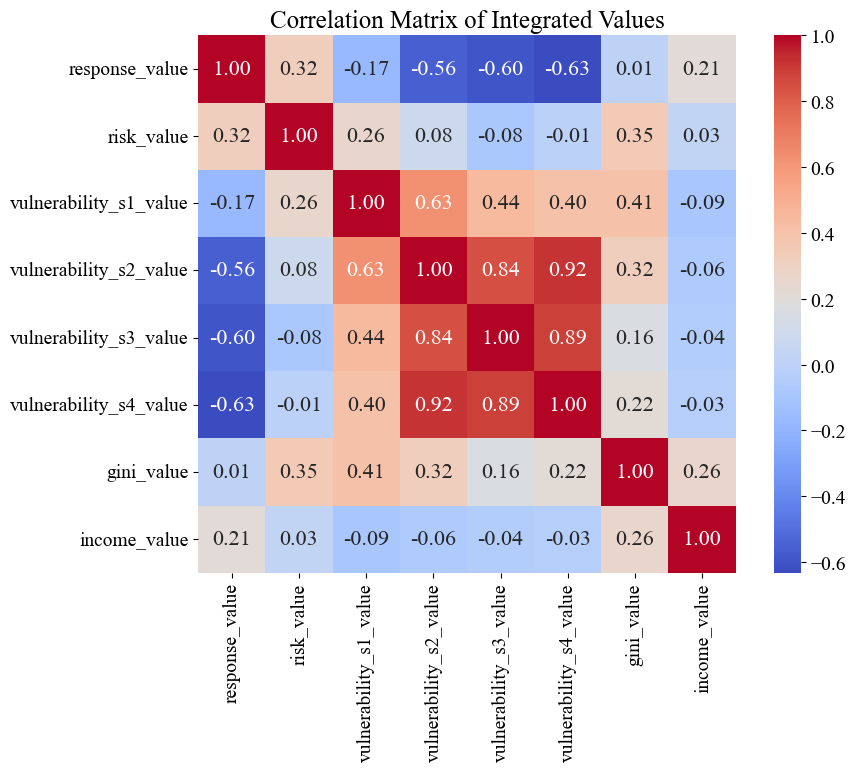

In [97]:
# Summary statistics of the integrated map
print(f"Total hexagons in integrated map: {len(integrated_grid_save)}")

# Basic statistics for each value column
print("\nResponse value statistics:")
print(integrated_grid_save['response_value'].describe())

print("\nRisk value statistics:")
print(integrated_grid_save['risk_value'].describe())

# print("\nVulnerability value statistics:")
# print(integrated_grid_save['vulnerability_value'].describe())
for i in range(1, 5):
    print(f"\nVulnerability S{i} value statistics:")
    print(integrated_grid_save[f"vulnerability_s{i}_value"].describe())

print("\nGini value statistics:")
print(integrated_grid_save['gini_value'].describe())

print("\nIncome value statistics:")
print(integrated_grid_save['income_value'].describe())

# Check for any remaining NA values
print("\nMissing values count:")
print(integrated_grid_save.isna().sum())

# Correlation matrix between the different values
vulnerability_columns = [f"vulnerability_s{i}_value" for i in range(1, 5)]
correlation_columns = (
    ["response_value", "risk_value"]
    + vulnerability_columns
    + ["gini_value", "income_value"]
)

print("\nCorrelation matrix between layers:")
correlation_matrix = integrated_grid_save[correlation_columns].corr()


# Plot the correlation matrix
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix of Integrated Values')
plt.tight_layout()
plt.show()